# Refined Stage 3I - do context and horizon effects depend on granularity? (RQ2, objective O4)

RQ2 has two halves. The first — how context length and horizon affect accuracy — is answered
by 3B and 3C. The second is:

> "...and how do these effects **interact with temporal granularity**?"

Objective O4 states it as *"quantify how context length and forecast horizon affect accuracy,
**crossed with granularity**"*.

**This notebook exists because that test was never run.** Stage 3H crosses context against
*horizon*, at native resolution only, and its header wrongly claims to answer this half of
RQ2. It does not: with a single granularity in the data, a granularity interaction cannot be
estimated. The evidence needed has been sitting in 3B and 3C from the start — both sweep all
three granularities — and requires no additional inference.

### How the test is done, and why twice

The obvious approach is to fit `log relMAE ~ log(factor) x granularity` over every window and
read off the interaction p-value. That treats ~7,000 windows as independent observations.
**They are not.** Rolling origins overlap, and the same five series recur at every granularity,
so the effective sample size is far smaller than the row count and the p-values are
anti-conservative.

So the interaction is tested at two levels:

| level | unit | strength | weakness |
|---|---|---|---|
| **A — window level** | one forecast | high resolution, shows effect size | p-values too small; windows not independent |
| **B — series level** | one series | correct unit; granularities are paired within a series | only 5 series, so power is low by construction |

**Level B governs the claim.** Level A is reported for effect size and to show what an
uncorrected analysis would have concluded. Where they disagree, the honest statement is that
the effect is visible but not established at the series level — which is a statement about the
five-series design, not about the effect.

In [1]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) -- restart the kernel and Run All")
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
GRAN_C  = {"native": "#dc2626", "1h": "#2563eb", "1D": "#16a34a"}
print(f"common module {C.__version__} from {C.__file__}")

def load_clean(path):
    """Scored, non-degenerate windows with a usable relMAE."""
    d = pd.read_csv(path)
    n0 = len(d)
    d = d[~d.degenerate].dropna(subset=["relMAE"])
    d = d[d.relMAE > 0]                      # log-scale analysis needs strictly positive
    print(f"{path}: {n0:,} rows -> {len(d):,} usable "
          f"({100*(n0-len(d))/n0:.1f}% dropped: degenerate or no benchmark)")
    return d

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [2]:
B = load_clean("refined_stage3b_context_sweep.csv")     # context swept, horizon fixed
Cc = load_clean("refined_stage3c_horizon_sweep.csv")    # horizon swept, context fixed per cell

for nm, d, f in [("3B", B, "context_steps"), ("3C", Cc, "horizon_steps")]:
    g = d.groupby("gran")[f].agg(["nunique", "min", "max"])
    print(f"\n{nm}: granularities present = {sorted(d.gran.unique())}")
    print(g.to_string())
assert d.gran.nunique() > 1, "a granularity interaction needs more than one granularity"

refined_stage3b_context_sweep.csv: 24,300 rows -> 18,675 usable (23.1% dropped: degenerate or no benchmark)
refined_stage3c_horizon_sweep.csv: 23,400 rows -> 18,162 usable (22.4% dropped: degenerate or no benchmark)

3B: granularities present = ['1D', '1h', 'native']
        nunique  min   max
gran                      
1D            5  128  2048
1h            5  128  2048
native        5  128  2048

3C: granularities present = ['1D', '1h', 'native']
        nunique  min  max
gran                     
1D            4    6   48
1h            4    6   48
native        4    6   48


## 1. The picture first

If the curves for the three granularities are parallel, the factor acts the same way at every
resolution and there is no interaction. If they fan out or cross, there is.

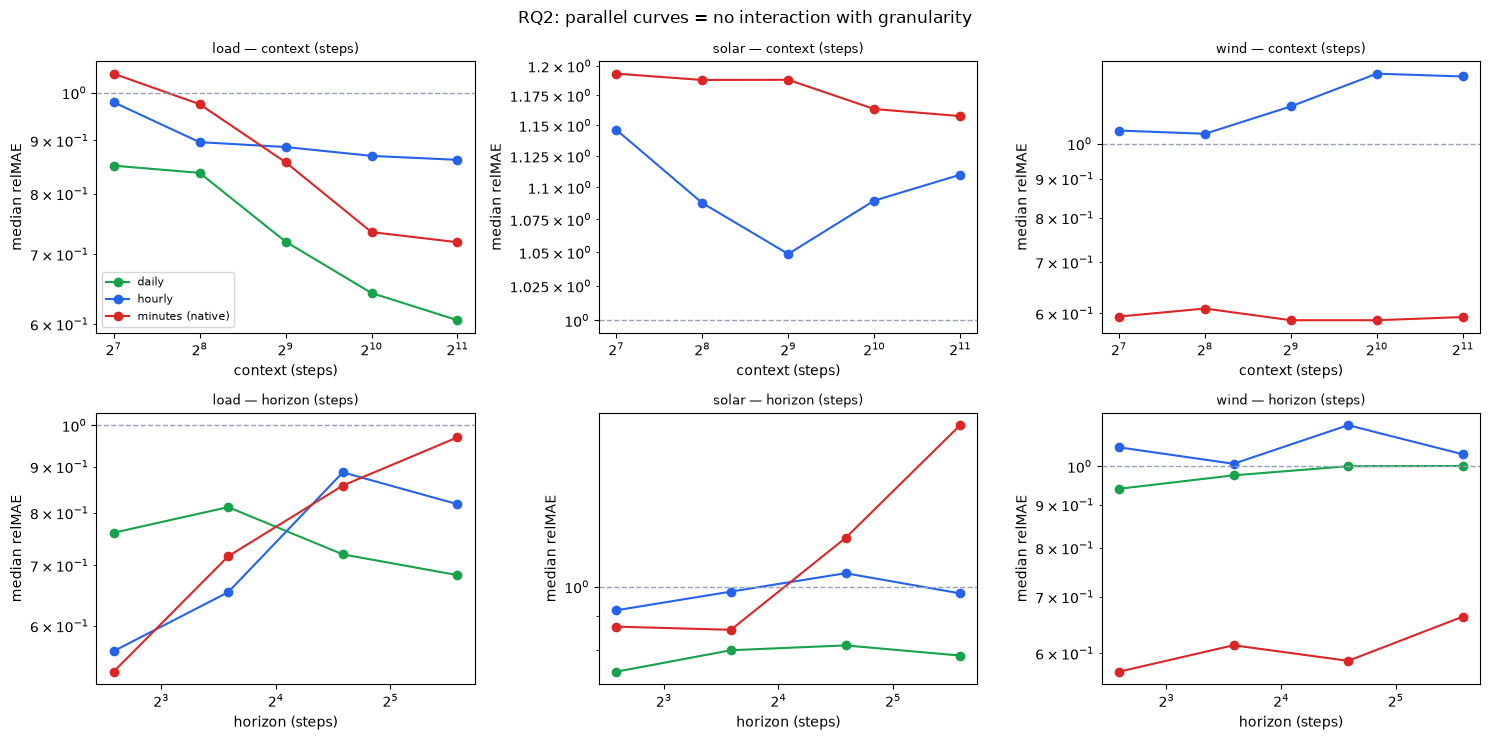

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), squeeze=False)
for row, (d, f, lab) in enumerate([(B, "context_steps", "context (steps)"),
                                   (Cc, "horizon_steps", "horizon (steps)")]):
    for col, et in enumerate(sorted(d.etype.unique())):
        ax = axes[row][col]
        sub = d[d.etype == et]
        for gk, g in sub.groupby("gran"):
            y = g.groupby(f)["relMAE"].median()
            ax.plot(y.index, y.values, marker="o", color=GRAN_C.get(gk),
                    label=C.GRANULARITIES[gk]["label"])
        ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
        ax.set_xscale("log", base=2); ax.set_yscale("log")
        ax.set_title(f"{et} — {lab}", fontsize=9)
        ax.set_xlabel(lab); ax.set_ylabel("median relMAE")
axes[0][0].legend(fontsize=8)
plt.suptitle("RQ2: parallel curves = no interaction with granularity")
plt.tight_layout(); plt.show()

## 2. Level A - window-level interaction

`log₁₀ relMAE ~ log₂(factor) × granularity`, compared against the additive model by likelihood
ratio. Reported with the caveat above: these p-values assume independent windows and are
therefore optimistic. The **ΔR²** column is the honest part of this table — it says how much
the interaction actually explains.

In [4]:
import statsmodels.formula.api as smf

def level_a(d, factor):
    rows = []
    for et, g in d.groupby("etype"):
        # NOTE: the formula must not use patsy's C() categorical operator here — the
        # common module is imported as `C`, and patsy would resolve C(gr) to the module.
        # A string column is treated as categorical by patsy anyway.
        g = g.assign(y=np.log10(g.relMAE), lx=np.log2(g[factor]),
                     gr=g.gran.astype(str))
        if g.gr.nunique() < 2:
            continue
        m0 = smf.ols("y ~ lx + gr", data=g).fit()
        m1 = smf.ols("y ~ lx * gr", data=g).fit()
        lr = m1.compare_lr_test(m0)
        rows.append({"etype": et, "n_windows": len(g), "n_series": g.series_id.nunique(),
                     "R2_additive": m0.rsquared, "R2_interaction": m1.rsquared,
                     "dR2": m1.rsquared - m0.rsquared, "p_window_level": lr[1]})
    return pd.DataFrame(rows)

A_ctx = level_a(B, "context_steps").assign(factor="context")
A_hor = level_a(Cc, "horizon_steps").assign(factor="horizon")
A = pd.concat([A_ctx, A_hor], ignore_index=True)
print(A[["factor", "etype", "n_windows", "n_series", "R2_additive",
         "R2_interaction", "dR2", "p_window_level"]].round(5).to_string(index=False))
print("\nThese p-values are ANTI-CONSERVATIVE — windows within a series overlap and repeat.")
print("Read dR2 for practical importance, and section 3 for inference.")

 factor etype  n_windows  n_series  R2_additive  R2_interaction     dR2  p_window_level
context  load       6750         5      0.05026         0.05446 0.00420         0.00000
context solar       5880         5      0.00555         0.00713 0.00158         0.00222
context  wind       6045         5      0.14927         0.14948 0.00020         0.22818
horizon  load       7080         5      0.01236         0.02418 0.01182         0.00000
horizon solar       5166         5      0.06028         0.07966 0.01938         0.00000
horizon  wind       5916         5      0.12991         0.13066 0.00076         0.07641

These p-values are ANTI-CONSERVATIVE — windows within a series overlap and repeat.
Read dR2 for practical importance, and section 3 for inference.


## 3. Level B - series level, which is the unit that governs the claim

For each series, the factor's slope is estimated separately at each granularity. Because every
series is observed at all three granularities, the slopes are **paired within series**, and the
question "does the slope depend on granularity" becomes a paired comparison across five blocks.

A Friedman test is the right instrument: it is non-parametric, it respects the pairing, and it
makes no assumption that the slopes are normally distributed.

**Power note, stated plainly:** with five series the smallest p-value a Friedman test on three
groups can return is about 0.008. So the design *can* reach significance, but only for a
consistent effect. A null here means "not established with five series", not "no effect".

In [5]:
from scipy.stats import friedmanchisquare, wilcoxon

def slopes(d, factor):
    """One OLS slope of log10(relMAE) on log2(factor) per (etype, gran, series)."""
    out = []
    for (et, gk, sid), g in d.groupby(["etype", "gran", "series_id"]):
        if g[factor].nunique() < 2 or len(g) < 4:
            continue
        x = np.log2(g[factor].values); y = np.log10(g.relMAE.values)
        b = np.polyfit(x, y, 1)[0]
        out.append({"etype": et, "gran": gk, "series_id": sid, "slope": b, "n": len(g)})
    return pd.DataFrame(out)

def level_b(d, factor, label):
    S = slopes(d, factor)
    print(f"\n=== {label}: per-series slope of log10(relMAE) on log2({factor}) ===")
    piv = S.pivot_table(index=["etype", "series_id"], columns="gran", values="slope")
    print(piv.round(4).to_string())
    rows = []
    for et, g in S.groupby("etype"):
        w = g.pivot_table(index="series_id", columns="gran", values="slope").dropna()
        if w.shape[1] < 2 or len(w) < 3:
            rows.append({"etype": et, "n_series": len(w), "n_gran": w.shape[1],
                         "test": "-", "stat": np.nan, "p_series_level": np.nan,
                         "min_possible_p": np.nan,
                         "note": "too few series or granularities"}); continue
        if w.shape[1] >= 3:
            test = "Friedman"
            st, p = friedmanchisquare(*[w[c].values for c in w.columns])
            floor = np.nan
        else:
            # Only two granularities survive here: daily is excluded from the CONTEXT
            # sweep for solar and wind, because one calendar year cannot hold two grid
            # contexts. Wilcoxon signed-rank is the correct paired test for two groups.
            test = "Wilcoxon"
            a_, b_ = w.columns[0], w.columns[1]
            st, p = wilcoxon(w[a_].values, w[b_].values)
            floor = 2.0 ** (1 - len(w))      # smallest attainable two-sided p at this n
        rows.append({"etype": et, "n_series": len(w), "n_gran": w.shape[1],
                     "test": test, "stat": st, "p_series_level": p,
                     "min_possible_p": floor,
                     "note": "; ".join(f"{c}:{w[c].median():+.3f}" for c in w.columns)})
    return pd.DataFrame(rows).assign(factor=label)

B_ctx = level_b(B, "context_steps", "context")
B_hor = level_b(Cc, "horizon_steps", "horizon")
Bl = pd.concat([B_ctx, B_hor], ignore_index=True)
print("\n=== Paired test: does the slope depend on granularity? ===")
print(Bl[["factor", "etype", "n_series", "n_gran", "test", "stat",
          "p_series_level", "min_possible_p", "note"]].round(4).to_string(index=False))
print("\n'note' gives the median per-series slope at each granularity.")
print("Negative slope = the factor IMPROVES accuracy; positive = it HARMS accuracy.")
print("\nPOWER FLOOR: with 5 series a two-sided Wilcoxon cannot return p < 0.0625, so a")
print("two-granularity cell CANNOT reach significance at alpha = 0.05 however large the")
print("effect. Where min_possible_p exceeds 0.05, read the slopes, not the p-value, and")
print("treat it as an argument for evaluating more series - not as evidence of no effect.")


=== context: per-series slope of log10(relMAE) on log2(context_steps) ===
gran                 1D      1h  native
etype series_id                        
load  0         -0.0528 -0.0327 -0.0541
      1         -0.0531 -0.0192 -0.0533
      2         -0.0511 -0.0039 -0.0375
      3         -0.0441 -0.0173 -0.0553
      4         -0.0477 -0.0076 -0.0559
solar 0             NaN -0.0063 -0.0412
      1             NaN -0.0068 -0.0374
      2             NaN  0.0008 -0.0297
      3             NaN -0.0030 -0.0343
      4             NaN  0.0005 -0.0459
wind  0             NaN  0.0721 -0.0016
      1             NaN  0.0046  0.0060
      2             NaN -0.0274  0.0614
      3             NaN -0.0153 -0.0048
      4             NaN  0.0548     NaN

=== horizon: per-series slope of log10(relMAE) on log2(horizon_steps) ===
gran                 1D      1h  native
etype series_id                        
load  0         -0.0217  0.0472  0.1025
      1         -0.0413  0.0625  0.0570
      2   

## 4. Verdict, with multiplicity control

Six tests are performed (3 energy types × 2 factors). Holm correction is applied to the
series-level p-values, which are the ones the claim rests on.

In [6]:
def holm(p):
    p = np.asarray(p, dtype=float); ok = ~np.isnan(p)
    out = np.full(p.shape, np.nan); idx = np.argsort(p[ok]); m = ok.sum()
    adj = np.empty(m); run = 0.0
    vals = p[ok][idx]
    for r, v in enumerate(vals):
        run = max(run, (m - r) * v); adj[r] = min(1.0, run)
    tmp = np.empty(m); tmp[idx] = adj; out[ok] = tmp
    return out

V = Bl.merge(A[["factor", "etype", "dR2", "p_window_level"]], on=["factor", "etype"], how="left")
V["p_series_holm"] = holm(V.p_series_level.values)
V["verdict"] = np.where(V.p_series_holm < 0.05, "interaction established",
                 np.where(V.p_window_level < 0.05,
                          "visible at window level, NOT established with 5 series",
                          "no evidence"))
print(V[["factor", "etype", "dR2", "p_window_level", "p_series_level",
         "p_series_holm", "verdict"]].round(5).to_string(index=False))
V.to_csv("refined_stage3i_granularity_interaction.csv", index=False)

est = int((V.p_series_holm < 0.05).sum())
print(f"\n{est} of {V.p_series_level.notna().sum()} tests establish an interaction at the "
      f"series level after Holm correction.")
print("\nFor RQ2, report the series-level verdict. Quote the window-level p-value only")
print("alongside its caveat — on its own it would overstate what 5 series can support.")

 factor etype     dR2  p_window_level  p_series_level  p_series_holm                                                verdict
context  load 0.00420         0.00000         0.01500        0.08997 visible at window level, NOT established with 5 series
context solar 0.00158         0.00222         0.06250        0.18750 visible at window level, NOT established with 5 series
context  wind 0.00020         0.22818         0.62500        0.94473                                            no evidence
horizon  load 0.01182         0.00000         0.02237        0.08997 visible at window level, NOT established with 5 series
horizon solar 0.01938         0.00000         0.01500        0.08997 visible at window level, NOT established with 5 series
horizon  wind 0.00076         0.07641         0.47237        0.94473                                            no evidence

0 of 6 tests establish an interaction at the series level after Holm correction.

For RQ2, report the series-level verdict. Quote t

## 5. In duration units

RQ2 asks for both observation counts and real-world duration. The same slopes, expressed as
the change in relMAE per doubling of *time* rather than per doubling of *steps* — which is the
form an operator can act on.

In [7]:
t = (pd.concat([B.assign(factor="context", steps=B.context_steps, dur=B.history_minutes),
                Cc.assign(factor="horizon", steps=Cc.horizon_steps, dur=Cc.lead_minutes)])
       .groupby(["factor", "etype", "gran", "steps"])
       .agg(duration_min=("dur", "first"), relMAE=("relMAE", "median"),
            n=("relMAE", "size")).reset_index())
t["duration"] = t.duration_min.map(C.human_duration)
print(t[["factor", "etype", "gran", "steps", "duration", "relMAE", "n"]]
      .round(3).to_string(index=False))
t.to_csv("refined_stage3i_duration_units.csv", index=False)

 factor etype   gran  steps duration  relMAE    n
context  load     1D    128  128.0 d   0.851  450
context  load     1D    256  256.0 d   0.838  450
context  load     1D    512  512.0 d   0.720  450
context  load     1D   1024 1024.0 d   0.642  450
context  load     1D   2048 2048.0 d   0.605  450
context  load     1h    128    5.3 d   0.979  450
context  load     1h    256   10.7 d   0.896  450
context  load     1h    512   21.3 d   0.887  450
context  load     1h   1024   42.7 d   0.870  450
context  load     1h   2048   85.3 d   0.862  450
context  load native    128    2.7 d   1.043  450
context  load native    256    5.3 d   0.975  450
context  load native    512   10.7 d   0.858  450
context  load native   1024   21.3 d   0.735  450
context  load native   2048   42.7 d   0.719  450
context solar     1h    128    5.3 d   1.146  450
context solar     1h    256   10.7 d   1.088  450
context solar     1h    512   21.3 d   1.049  450
context solar     1h   1024   42.7 d   1.089  450


## 6. What to report for RQ2

- The first half of RQ2 comes from 3B and 3C: which lever matters, and by how much.
- **This notebook supplies the second half.** State the series-level verdict, and say openly
  that five series is the binding constraint on power — that is a limitation of the design,
  not a property of the models.
- The `dR2` column is what stops a significant result being oversold. An interaction that is
  significant but moves R² by 0.001 is a statistical fact, not a deployment consideration.
- A null for wind is a legitimate finding and should be reported as one: at wind's resolutions
  the context and horizon effects do not depend on how the signal is aggregated.